In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from ir_rpp.preprocessing import load_dfs, load_labels_and_runs, get_paths
from ir_rpp.pref_eval.util.trec_io import read_qrels, read_run
from ir_rpp.statistical_tests import run_ttests
from ir_rpp.pref_eval.measures.single_topic_metrics import (
    d_rank_biased_precision_list,
    d_ndcg_list,
    d_sign_list,
)

from tqdm.auto import tqdm
import glob

%load_ext autoreload
%autoreload 2

In [2]:
# summary, df_preference, df_metric = load_dfs(
#     "deep-docs",
#     2019,
#     binary_relevance=1,
#     metrics=[
#         # "rpp",
#         # "invrpp",
#         # "dcgrpp",
#         # "ap",
#         # "ndcg",
#         # "rr",
#         "rbp",
#     ],
# )

In [3]:
runs_path, qrels_file = get_paths("deep-docs", 2019)
qrels = read_qrels(qrels_file, 1, None, full=False)

run_files = glob.glob(str(runs_path / "*.gz"))
runs = {}
for run_file in tqdm(run_files, desc="Reading run files"):
    runid, run = read_run(run_file, qrels, None)
    runs[runid] = run

Reading run files:   0%|          | 0/38 [00:00<?, ?it/s]

In [4]:
qid = "19335"
runid_i = "bm25_marcomb"
runid_j = "TUW19-d2-f"
rv_i = runs[runid_i][qid]
rv_j = runs[runid_j][qid]

In [14]:
runids = list(runs.keys())
qids = list(runs[runids[0]].keys())
res = []
for qid in tqdm(qids, "Iterating over qids"):
    for i in range(len(runids)):
        runid_i = runids[i]
        rv_i = runs[runid_i][qid]

        for j in range(i + 1, len(runids)):
            runid_j = runids[j]
            rv_j = runs[runid_j][qid]
            ll = d_ndcg_list(rv_i, rv_j)
            res.append(ll)
result = np.concatenate(res)
result = np.concatenate([result, -result])

Iterating over qids:   0%|          | 0/43 [00:00<?, ?it/s]

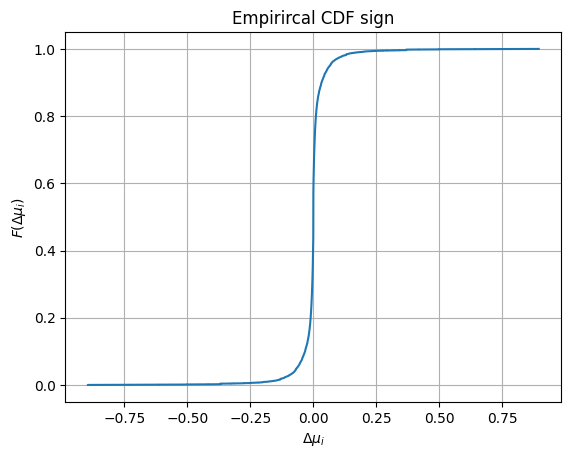

In [15]:
def plot_cdf(x, title="Empirical CDF"):
    x = np.sort(x)
    cdf = np.arange(1, len(x) + 1) / len(x)

    plt.plot(x, cdf)
    plt.title(title)
    plt.xlabel(r"$\Delta \mu_i$")
    plt.ylabel(r"$F(\Delta \mu_i)$")
    plt.grid()
    plt.show()


plot_cdf(result, title="Empirircal CDF sign")

In [ ]:
flat = [item for sublist in res for item in sublist]
len(flat)

4637691

In [61]:
max(flat)

0.5

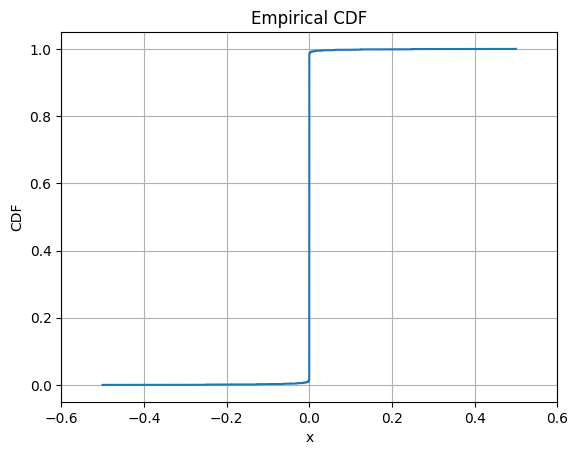

In [62]:
import numpy as np
import matplotlib.pyplot as plt

# get values as numpy array
rbp = np.array(flat)

# make distribution symmetric
rbp = np.concatenate([rbp, -rbp])

# sort values
x = np.sort(rbp)

# empirical CDFF b
cdf = np.arange(1, len(x) + 1) / len(x)

# plot
plt.step(x, cdf, where="post")

plt.xlabel("x")
plt.xlim([-0.6, 0.6])
plt.ylabel("CDF")
plt.title("Empirical CDF")
plt.grid(True)

plt.show()

In [23]:
df_ttest, df_summary = run_ttests(df_preference)

In [ ]:
print(df_summary[["rpp", "dcgrpp", "invrpp", "ap", "ndcg", "rr"]])

metric         rpp  dcgrpp  invrpp     ap   ndcg     rr
significant  49.84   48.79   43.58  39.08  46.91  21.71


**Implementation of left side of figure 2 from the paper**

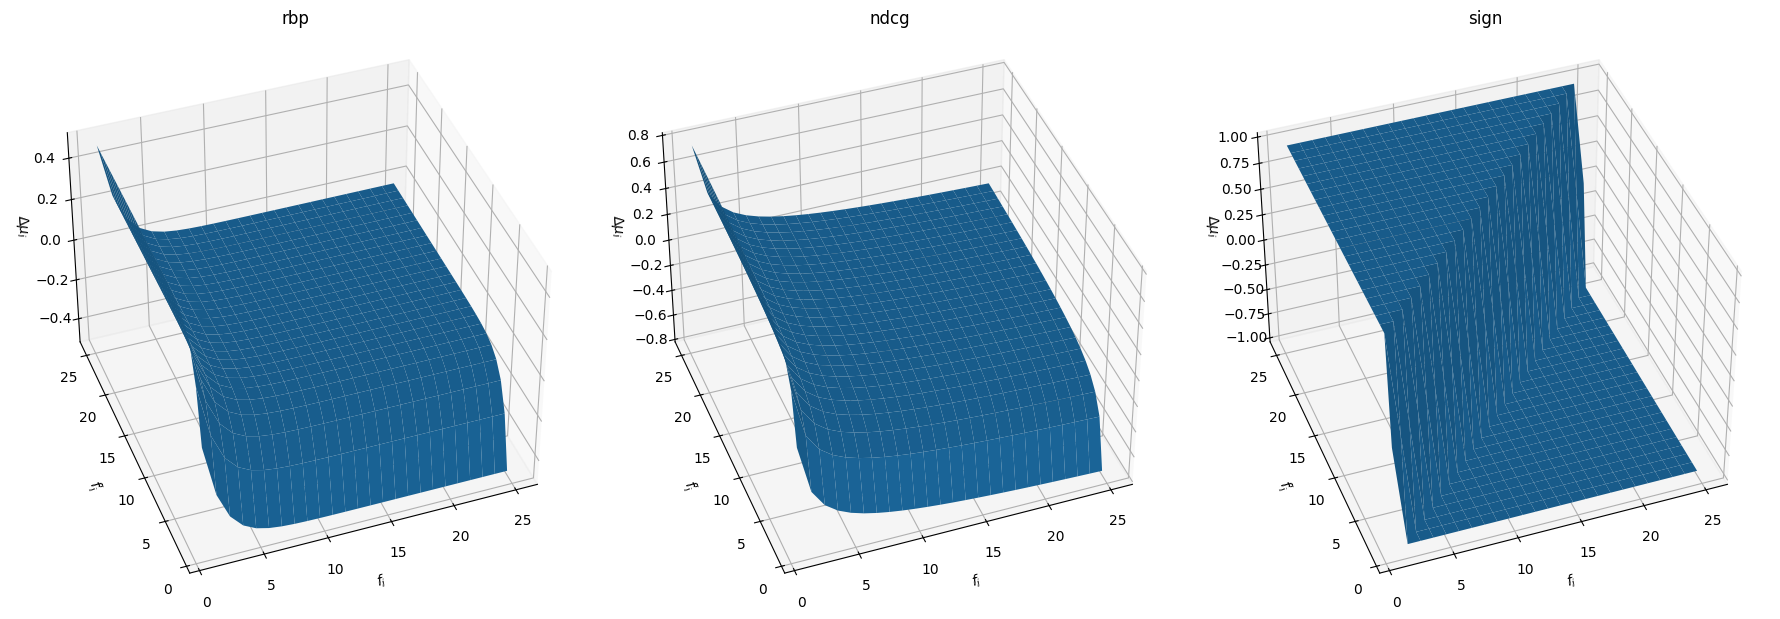

In [6]:
def delta_mu_rbp(f, f_prime, gamma: float = 0.5):
    return gamma**f - gamma**f_prime


def delta_mu_ndcg(f, f_prime):
    return 1 / np.log2(f + 1) - 1 / np.log2(f_prime + 1)


def delta_mu_sign(f, f_prime):
    return np.sign(f_prime - f)


functions = {
    "rbp": delta_mu_rbp,
    "ndcg": delta_mu_ndcg,
    "sign": delta_mu_sign,
}

f, f_prime = np.meshgrid(np.arange(1, 26), np.arange(1, 26))


fig, axes = plt.subplots(
    1,
    len(functions),
    figsize=(18, 6),
    subplot_kw={"projection": "3d"},
)

for ax, (name, func) in zip(axes.flatten(), functions.items()):
    ax.set_title(name)
    z = func(f, f_prime)
    ax.plot_surface(f, f_prime, z)
    ax.set_xlabel("$f_i$")
    ax.set_ylabel("$f_i'$")
    ax.set_zlabel(r"$\Delta \mu_i$")

    ax.view_init(elev=40, azim=-110)

fig.tight_layout()
plt.show()